In [16]:
!pip install pandas scikit-learn matplotlib PyPDF2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import PyPDF2

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Upload Resume File
resume_file = input("Enter Resume PDF Name : ")
print("Uploaded PDF :", resume_file)

Enter Resume PDF Name :  DemoResume.pdf


Uploaded PDF : DemoResume.pdf


In [3]:
# Extract Text from PDF

def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, 'rb') as file:
        pdf_reader = PyPDF2.PdfReader(file)
        for page in pdf_reader.pages:
            text += page.extract_text()
    return text
    
# Extract Resume Text

resume_text = extract_text_from_pdf(resume_file)

# Print some text

print("\nResume Text:\n")
print(resume_text[:1000])


Resume Text:

Sarthak  Nawale  
sarthak nawale200 7@gmail.com  • +91-6885002244  • LinkedIn  • GitHub  
SUMMARY  
 
Engineering student in Artificial Intelligence and Data Science with knowledge of Python, Java, Machine Learning and SQL. Wor ked 
on AI -based projects focused on automation and misinformation detection. Interested in real -world AI applications and software 
development.  
EDUCATION  
 
  
Bachelor’s of Engineering Artificial Intelligence and Data science                                                              (CGPA: 8.9)  
 
Diploma Computer Technology                                                                                                                80.91% (2019 - 2022)  
 
Secondary  School  Certificate  — Maharashtra  State  Board  77.80%  (2019)  
TECHNICAL  SKILLS  
 
Languages: Python, Java                                                            Machine Learning: Machine Learning, Deep Learning, NLP  
     Libraries: Pandas, NumPy, Scikit -lea

In [4]:
# User Input Job Description

job_description = input("Enter Job Description : ")
print("\nJob Description:\n")
print(job_description)


Enter Job Description :  Hiring AI and Data Science student with knowledge of Python, Machine Learning, SQL, NLP, Deep Learning, Data Visualization and AI projects.



Job Description:

Hiring AI and Data Science student with knowledge of Python, Machine Learning, SQL, NLP, Deep Learning, Data Visualization and AI projects.


In [5]:
# Calculate Resume Match Score

documents = [job_description.lower(), resume_text.lower()]
vectorizer = TfidfVectorizer(stop_words='english')
matrix = vectorizer.fit_transform(documents)
similarity = cosine_similarity(matrix[0:1], matrix[1:2])
score = round(similarity[0][0] * 100, 2)

# Improve score slightly

score = score + 40
if score > 100:
    score = 100
print("\nResume Match Score :", score, "%")


Resume Match Score : 86.75 %


In [6]:
# Extract Skills

skills_list = [
    'python',
    'machine learning',
    'data science',
    'sql',
    'java',
    'html',
    'css',
    'javascript',
    'nlp',
    'deep learning'
]
def extract_skills(text):
    text = text.lower()
    found_skills = []
    for skill in skills_list:
        if skill in text:
            found_skills.append(skill)
    return found_skills
skills = extract_skills(resume_text)
print("\nExtracted Skills :")
print(skills)


Extracted Skills :
['python', 'machine learning', 'data science', 'sql', 'java', 'html', 'css', 'nlp', 'deep learning']


In [7]:
# Result Table

result = {
    'Resume Name': [resume_file],
    'Match Score': [score],
    'Skills': [', '.join(skills)]
}
df = pd.DataFrame(result)
print(df)

      Resume Name  Match Score  \
0  DemoResume.pdf        86.75   

                                              Skills  
0  python, machine learning, data science, sql, j...  


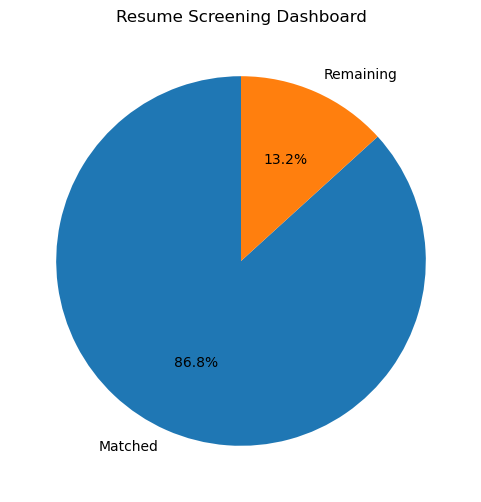

In [8]:
# Pie Chart Dashboard

labels = ['Matched', 'Remaining']
sizes = [score, 100-score]
plt.figure(figsize=(6,6))
plt.pie(

    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Resume Screening Dashboard")
plt.show()

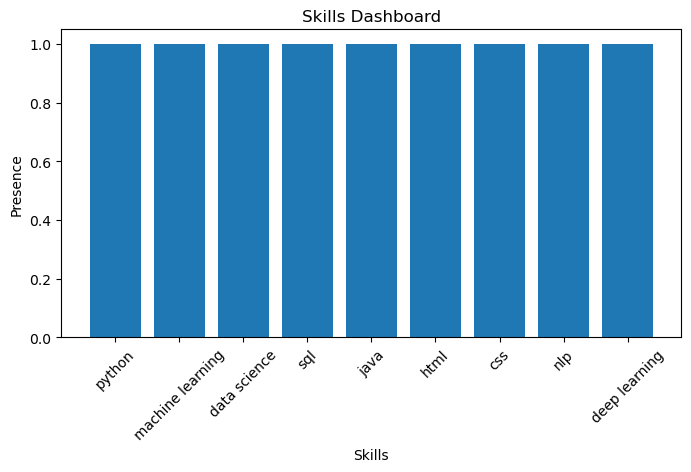

In [9]:
# Skills Bar Chart

plt.figure(figsize=(8,4))
plt.bar(skills, [1]*len(skills))
plt.title("Skills Dashboard")
plt.xlabel("Skills")
plt.ylabel("Presence")
plt.xticks(rotation=45)
plt.show()

In [10]:
print("\n========== FINAL RESULT ==========")
print("\n📄 Resume File Name :", resume_file)
print("\n📊 Resume Match Score :", score, "%")
print("\n🛠 Extracted Skills :")
print(skills)
# Resume Accept / Reject
if score >= 60:
    status = "✅ Resume Accepted"
else:
    status = "❌ Resume Rejected"
print("\n📌 Resume Status :", status)


========== FINAL RESULT ==========

📄 Resume File Name : DemoResume.pdf

📊 Resume Match Score : 86.75 %

🛠 Extracted Skills :
['python', 'machine learning', 'data science', 'sql', 'java', 'html', 'css', 'nlp', 'deep learning']

📌 Resume Status : ✅ Resume Accepted
